In [55]:
import yfinance as yf
import numpy as np
import pandas as pd


tickers = [
    'AAPL', 'MSFT', 'GOOG', 'AMZN', 'NVDA',
    'JPM', 'BAC', 'GS', 'WFC', 'MS',
    'JNJ', 'UNH', 'PFE', 'MRK', 'ABBV',
    'XOM', 'CVX', 'COP', 'SLB', 'EOG',
    'PG', 'KO', 'PEP', 'WMT', 'COST',
    'HD', 'MCD', 'NKE', 'SBUX', 'TGT'
]

raw = yf.download(tickers, start='2020-01-01', end='2025-12-31', progress=False)['Close']
returns = np.log(raw / raw.shift(1)).dropna()
returns.head()


Ticker,AAPL,ABBV,AMZN,BAC,COP,COST,CVX,EOG,GOOG,GS,...,PEP,PFE,PG,SBUX,SLB,TGT,UNH,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-03,-0.009769,-0.009537,-0.012213,-0.020982,0.003660,0.000823,-0.003465,0.010052,-0.004919,-0.011762,...,-0.001400,-0.005380,-0.006748,-0.005837,0.009662,-0.010446,-0.010171,-0.006158,-0.008867,-0.008072
2020-01-06,0.007937,0.007861,0.014776,-0.001434,0.011803,0.000274,-0.003394,0.039790,0.024358,0.010182,...,0.003826,-0.001285,0.001386,-0.007911,0.006390,-0.009503,0.006918,-0.006009,-0.002038,0.007649
2020-01-07,-0.004714,-0.005721,0.002089,-0.006622,0.000000,-0.001578,-0.012852,0.009565,-0.000624,0.006561,...,-0.015843,-0.003349,-0.006211,-0.003068,-0.005158,0.001779,-0.006055,-0.008320,-0.009308,-0.008218
2020-01-08,0.015958,0.007062,-0.007839,0.010059,-0.023438,0.011399,-0.011489,-0.022081,0.007850,0.009593,...,0.005136,0.007968,0.004254,0.011543,-0.029995,-0.003236,0.020865,0.003034,-0.003438,-0.015195
2020-01-09,0.021019,0.007678,0.004788,0.001714,0.017251,0.015923,-0.001616,0.010365,0.010984,0.020153,...,0.000668,-0.004362,0.010878,0.018394,0.011354,0.000810,-0.005694,-0.001705,0.010277,0.007626


In [56]:
mu = returns.mean().values
sigma = returns.std().values
Sigma = returns.cov().values

mu_ann = mu * 252
sigma_ann = sigma * np.sqrt(252)

mu_norm = mu_ann / sigma_ann
R_tilde = ((returns - returns.mean()) / returns.std()).values

print("mu_annual (first 5):", np.round(mu_ann[:5], 4))
print("sigma_annual (first 5):", np.round(sigma_ann[:5], 4))
print("mu_norm (first 5):", np.round(mu_norm[:5], 4))
print("Sigma diagonal (first 5):", np.round(np.diag(Sigma)[:5], 6))
print("Sigma min eigenvalue:", np.round(np.linalg.eigvalsh(Sigma).min(), 6))

mu_annual (first 5): [0.222  0.1993 0.15   0.0981 0.0974]
sigma_annual (first 5): [0.3175 0.2514 0.3568 0.3437 0.4281]
mu_norm (first 5): [0.6992 0.7927 0.4202 0.2854 0.2276]
Sigma diagonal (first 5): [0.0004   0.000251 0.000505 0.000469 0.000727]
Sigma min eigenvalue: 4e-05


In [57]:
def portfolio_return(subset, mu):
    # equal weight portfolio return for a given subset of asset indices
    return np.mean(mu[list(subset)])

def portfolio_variance(subset, Sigma):
    # equal weight portfolio variance for a given subset of asset indices
    idx = list(subset)
    sub_Sigma = Sigma[np.ix_(idx, idx)]
    k = len(idx)
    w = np.ones(k) / k
    return w @ sub_Sigma @ w

test_subset = [0, 1, 2, 3, 4]
print(f"Return: {round(portfolio_return(test_subset, mu_ann), 4)}")
print(f"Variance: {round(portfolio_variance(test_subset, Sigma), 6)}")
print(f"Volatility: {round(np.sqrt(portfolio_variance(test_subset, Sigma)) * np.sqrt(252), 4)}")


Return: 0.1534
Variance: 0.000225
Volatility: 0.2381


# A (BRUTE FORCE)

In [58]:
from itertools import combinations
import time

def brute_force(n, k, mu, Sigma, sigma2_max):
    # Enumerate all C(n,k) subsets.
    # Returns best subset, its return, and runtime.
    
    assets = list(range(n))
    best_return = -np.inf
    best_subset = None
    all_portfolios = []
    
    start = time.time()
    
    for subset in combinations(assets, k):
        ret = portfolio_return(subset, mu)
        var = portfolio_variance(subset, Sigma)
        all_portfolios.append((subset, ret, var))
        
        if var <= sigma2_max and ret > best_return:
            best_return = ret
            best_subset = subset
    
    runtime = time.time() - start
    
    # if no subset is feasible, just return best return ignoring constraint
    if best_subset is None:
        best_subset, best_return, _ = max(all_portfolios, key=lambda x: x[1])
    
    return best_subset, best_return, runtime, all_portfolios

n_test, k_test = 20, 5
assets_test = list(range(n_test))

print(f"Computing median var across C({n_test}, {k_test}) portfolios.")
variances = [portfolio_variance(s, Sigma[:n_test, :n_test]) for s in combinations(assets_test, k_test)]
sigma2_max = np.median(variances)
print(f"sigma2_max set to: {sigma2_max:.6f}")
print(f"Annualized vol budget: {np.sqrt(sigma2_max * 252):.4f}")



Computing median var across C(20, 5) portfolios.
sigma2_max set to: 0.000215
Annualized vol budget: 0.2327


In [60]:
from math import comb

def greedy(n, k, mu, Sigma, sigma2_max):
    # sequentially add the asset that maximally improves return s.t. risk constraint
    # if no feasible asset exists at a step then add the highest return asset regardless of constraint

    available = list(range(n))
    selected = []
    
    for _ in range(k):
        best_ret = -np.inf
        best_asset = None
        
        # try to find feasible addition
        for asset in available:
            candidate = selected + [asset]
            var = portfolio_variance(candidate, Sigma)
            ret = portfolio_return(candidate, mu)
            if var <= sigma2_max and ret > best_ret:
                best_ret = ret
                best_asset = asset
        
        if best_asset is None:
            best_asset = max(available, key=lambda a: mu[a])
        
        selected.append(best_asset)
        available.remove(best_asset)
    
    return tuple(selected), portfolio_return(selected, mu)


# experiment A
ns = [10, 15, 20, 25, 30]
ks = [5, 7, 10]
results_A = []

for n in ns:
    for k in ks:
        mu_n = mu_ann[:n]
        Sigma_n = Sigma[:n, :n]
        
        n_combos = comb(n, k)
        
        # brute force
        best_sub, best_ret, runtime, _ = brute_force(n, k, mu_n, Sigma_n, sigma2_max)
        
        # greedy
        greedy_sub, greedy_ret = greedy(n, k, mu_n, Sigma_n, sigma2_max)
        
        # greedy gap
        gap = (best_ret - greedy_ret) / abs(best_ret) if best_ret != 0 else 0
        
        results_A.append({
            'n': n,
            'k': k,
            'C(n,k)': n_combos,
            'best_return': round(best_ret, 4),
            'greedy_return': round(greedy_ret, 4),
            'greedy_gap': round(gap * 100, 2),
            'runtime_s': round(runtime, 3)
        })
        
        print(f"n={n}, k={k}: C({n},{k})={n_combos:,} | optimal={best_ret:.4f} | greedy={greedy_ret:.4f} | gap={gap*100:.2f}% | time={runtime:.3f}s")

n=10, k=5: C(10,5)=252 | optimal=0.2242 | greedy=0.2242 | gap=0.00% | time=0.006s
n=10, k=7: C(10,7)=120 | optimal=0.1956 | greedy=0.1956 | gap=0.00% | time=0.002s
n=10, k=10: C(10,10)=1 | optimal=0.1633 | greedy=0.1633 | gap=0.00% | time=0.000s
n=15, k=5: C(15,5)=3,003 | optimal=0.2242 | greedy=0.2038 | gap=9.12% | time=0.036s
n=15, k=7: C(15,7)=6,435 | optimal=0.2054 | greedy=0.1975 | gap=3.83% | time=0.078s
n=15, k=10: C(15,10)=3,003 | optimal=0.1734 | greedy=0.1731 | gap=0.15% | time=0.028s
n=20, k=5: C(20,5)=15,504 | optimal=0.2731 | greedy=0.2071 | gap=24.18% | time=0.138s
n=20, k=7: C(20,7)=77,520 | optimal=0.2585 | greedy=0.2078 | gap=19.61% | time=0.700s
n=20, k=10: C(20,10)=184,756 | optimal=0.2392 | greedy=0.2392 | gap=0.00% | time=1.727s
n=25, k=5: C(25,5)=53,130 | optimal=0.2731 | greedy=0.2071 | gap=24.18% | time=0.675s
n=25, k=7: C(25,7)=480,700 | optimal=0.2585 | greedy=0.2078 | gap=19.61% | time=4.311s
n=25, k=10: C(25,10)=3,268,760 | optimal=0.2392 | greedy=0.2392 | g

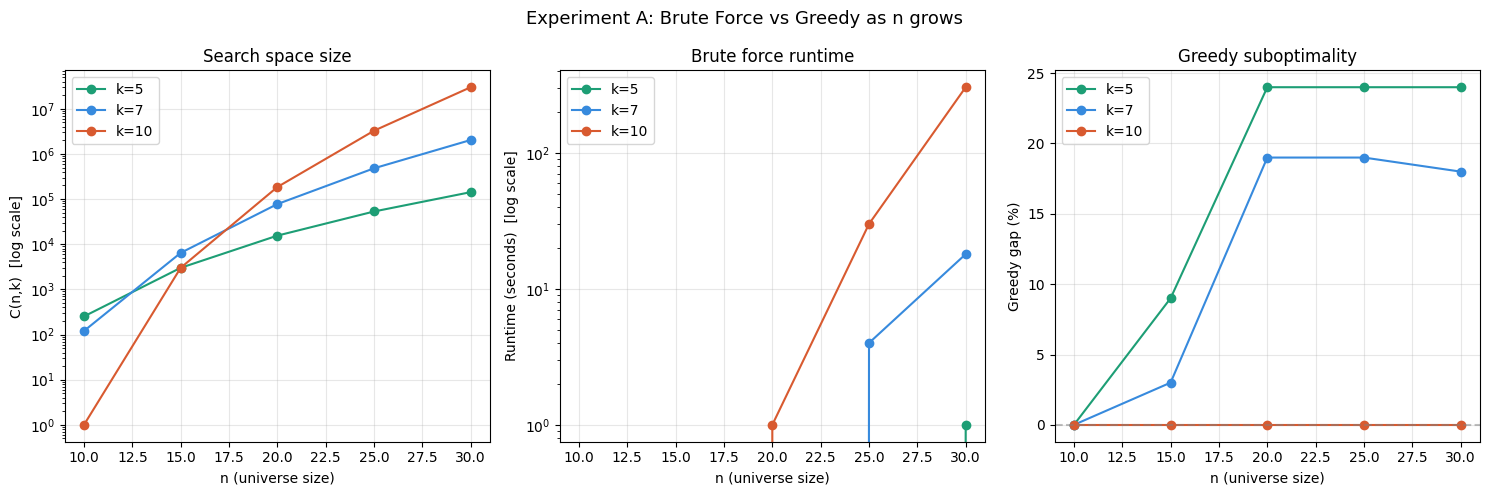

In [63]:
import matplotlib.pyplot as plt

results = [(
    (a['n']), int(a['k']), int(a['best_return']),
      int(a['greedy_return']), int(a['greedy_gap']), int(a['runtime_s'])
) for a in results_A]

colors={'k=5': '#1D9E75', 'k=7': '#378ADD', 'k=10': '#D85A30'}

def get(results, n, k, field):
    fields = ['n','k','optimal','greedy','gap','runtime']
    idx = fields.index(field)
    for row in results:
        if row[0]==n and row[1]==k:
            return row[idx]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Experiment A: Brute Force vs Greedy as n grows', fontsize=13)


ax = axes[0]
for k in ks:
    combos = [comb(n, k) for n in ns]
    ax.semilogy(ns, combos, marker='o', label=f'k={k}', color=colors[f'k={k}'])
ax.set_xlabel('n (universe size)')
ax.set_ylabel('C(n,k)  [log scale]')
ax.set_title('Search space size')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
for k in ks:
    runtimes = [get(results, n, k, 'runtime') for n in ns]
    ax.semilogy(ns, runtimes, marker='o', label=f'k={k}', color=colors[f'k={k}'])
ax.set_xlabel('n (universe size)')
ax.set_ylabel('Runtime (seconds) [log scale]')
ax.set_title('Brute force runtime')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[2]
for k in ks:
    gaps = [get(results, n, k, 'gap') for n in ns]
    ax.plot(ns, gaps, marker='o', label=f'k={k}', color=colors[f'k={k}'])
ax.set_xlabel('n (universe size)')
ax.set_ylabel('Greedy gap (%)')
ax.set_title('Greedy suboptimality')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('experiment_A.png', dpi=150, bbox_inches='tight')
plt.show()